In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
data_dir = "data/raw_images"

categories = ["waste", "non_waste"]

data = []
labels = []

for category in categories:
    path = os.path.join(data_dir, category)
    label = categories.index(category)

    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.resize(image, (128, 128))
        data.append(image)
        labels.append(label)

data = np.array(data) / 255.0
labels = np.array(labels)

print("Total Images:", len(data))
print("Waste images:", np.sum(labels == 0))
print("Non-waste images:", np.sum(labels == 1))

Total Images: 2314
Waste images: 1956
Non-waste images: 358


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)

y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1851
Test size: 463


In [4]:
# Data Augmentation — model ko diverse images dikhao
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

In [5]:
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Dense layers
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\VICTUS\Desktop\waste-detection-project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,466 (24.87 MB)

 Trainable params: 6,517,506 (24.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,           # 5 epochs tak improve nahi hua to rok do
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=8,            # zyada epochs, early stopping handle karega
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 730ms/step - accuracy: 0.8693 - loss: 0.4017 - val_accuracy: 0.8445 - val_loss: 3.3204 - learning_rate: 0.0010
Epoch 2/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 613ms/step - accuracy: 0.8995 - loss: 0.3096 - val_accuracy: 0.8445 - val_loss: 1.5579 - learning_rate: 0.0010
Epoch 3/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 623ms/step - accuracy: 0.9190 - loss: 0.2342 - val_accuracy: 0.8445 - val_loss: 1.0399 - learning_rate: 0.0010
Epoch 4/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 626ms/step - accuracy: 0.9281 - loss: 0.2361 - val_accuracy: 0.8445 - val_loss: 1.3841 - learning_rate: 0.0010
Epoch 5/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 608ms/step - accuracy: 0.9276 - loss: 0.2169 - val_accuracy: 0.8445 - val_loss: 1.6591 - learning_rate: 0.0010
Epoch 6/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 610ms/step - accuracy: 0.9314 - loss: 0.2075 - val_accuracy: 0.8467 - val_loss: 0.6957 - learning_rate: 0.0010
Epoch 7/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 613ms/step - accuracy: 0.9379 - loss: 0.2048 - 

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", round(accuracy * 100, 2), "%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9309 - loss: 0.3081
Test Accuracy: 93.09 %


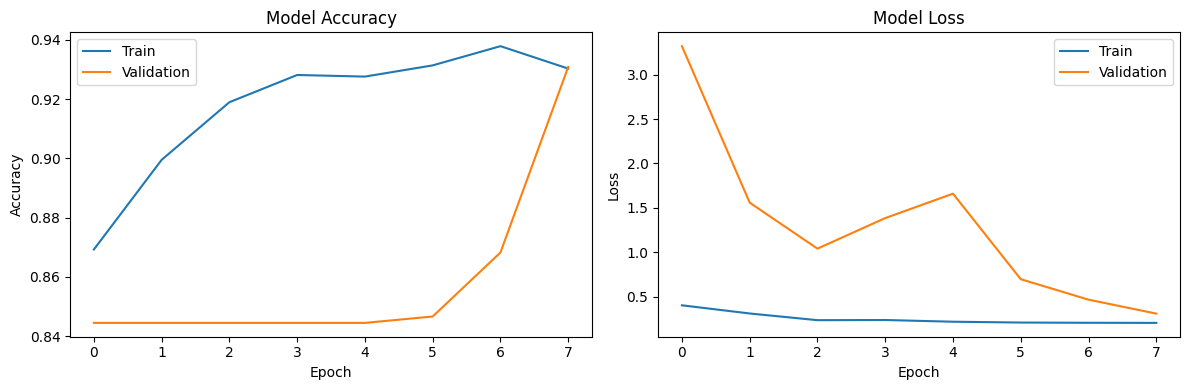

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
model.save("waste_model.h5")
print("Model saved as waste_model.h5")

Model saved as waste_model.h5


In [11]:
from tensorflow.keras.models import load_model

model = load_model("waste_model.h5")

def predict_image(img_path):
    image = cv2.imread(img_path)
    image = cv2.resize(image, (128, 128))
    image = image / 255.0
    image = np.reshape(image, (1, 128, 128, 3))

    prediction = model.predict(image)

    class_names = ["Waste", "Non Waste"]
    class_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    print("Prediction:", class_names[class_index])
    print("Confidence:", round(confidence, 2), "%")
    print("Waste prob:", round(float(prediction[0][0]) * 100, 2), "%")
    print("Non-waste prob:", round(float(prediction[0][1]) * 100, 2), "%")

# predict_image("path/to/test/image.jpg")